In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


#### **Phase 1: Data Collection and Exploratory Data Analysis (EDA)**

**Step 1 \- Data Import and Preprocessing**

1. **Dataset**&nbsp;  
   &nbsp;Load the dataset ([`Food_Delivery_Time_Prediction.csv`](https://drive.google.com/file/d/1gAJGXBob3zRpJkRWQhvf3a94PS6NhGjx/view?usp=sharing)).  
2. **Handle Missing Values**  
   &nbsp;Check for any missing or inconsistent values in columns such as `Distance`, `Delivery_Time`, etc. and decide how to handle them, either through imputation or deletion.

3. **Data Transformation**

   * **Encode Categorical Variables**: Use one-hot encoding or label encoding for variables like `Weather Conditions`, `Traffic Conditions`, `Vehicle Type`.  
   * **Normalize/Standardize Numeric Columns**: Normalize or standardize continuous features like `Distance`, `Delivery_sTime`, and `Order_Cost` for consistency.


In [50]:
df = pd.read_csv('Food_Delivery_Time_Prediction.csv')
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [51]:
df.columns

Index(['Order_ID', 'Customer_Location', 'Restaurant_Location', 'Distance',
       'Weather_Conditions', 'Traffic_Conditions',
       'Delivery_Person_Experience', 'Order_Priority', 'Order_Time',
       'Vehicle_Type', 'Restaurant_Rating', 'Customer_Rating', 'Delivery_Time',
       'Order_Cost', 'Tip_Amount'],
      dtype='str')

In [52]:
df.isna().sum()

Order_ID                      0
Customer_Location             0
Restaurant_Location           0
Distance                      0
Weather_Conditions            0
Traffic_Conditions            0
Delivery_Person_Experience    0
Order_Priority                0
Order_Time                    0
Vehicle_Type                  0
Restaurant_Rating             0
Customer_Rating               0
Delivery_Time                 0
Order_Cost                    0
Tip_Amount                    0
dtype: int64

In [53]:
df['Customer_Location_lat'] = df['Customer_Location'].apply(lambda x: x.split(',')[0][1:]).astype(float)
df['Customer_Location_lon'] = df['Customer_Location'].apply(lambda x: x.split(',')[1][:-1]).astype(float)

df['Restaurant_Location_lat'] = df['Restaurant_Location'].apply(lambda x: x.split(',')[0][1:]).astype(float)
df['Restaurant_Location_lon'] = df['Restaurant_Location'].apply(lambda x: x.split(',')[1][:-1]).astype(float)

df.drop(columns=['Customer_Location', 'Restaurant_Location'], inplace=True)

df.head()



,Order_ID,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Customer_Location_lat,Customer_Location_lon,Restaurant_Location_lat,Restaurant_Location_lon
0,ORD0001,1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54,17.030479,79.743077,12.358515,85.100083
1,ORD0002,21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02,15.398319,86.639122,14.174874,77.025606
2,ORD0003,6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17,15.687342,83.888808,19.594748,82.048482
3,ORD0004,13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23,20.415599,78.046984,16.915906,78.278698
4,ORD0005,6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34,14.786904,78.706532,15.206038,86.203182


In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    str    
 1   Distance                    200 non-null    float64
 2   Weather_Conditions          200 non-null    str    
 3   Traffic_Conditions          200 non-null    str    
 4   Delivery_Person_Experience  200 non-null    int64  
 5   Order_Priority              200 non-null    str    
 6   Order_Time                  200 non-null    str    
 7   Vehicle_Type                200 non-null    str    
 8   Restaurant_Rating           200 non-null    float64
 9   Customer_Rating             200 non-null    float64
 10  Delivery_Time               200 non-null    float64
 11  Order_Cost                  200 non-null    float64
 12  Tip_Amount                  200 non-null    float64
 13  Customer_Location_lat       200 non-null    fl

In [55]:
df.drop(columns=['Order_ID'], inplace=True)

num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(include=['object', 'string', 'str']).columns



In [56]:
print("Numerical columns:")
print(num_cols)
print("\nCategorical columns:")
print(cat_cols)

Numerical columns:
Index(['Distance', 'Delivery_Person_Experience', 'Restaurant_Rating',
       'Customer_Rating', 'Delivery_Time', 'Order_Cost', 'Tip_Amount',
       'Customer_Location_lat', 'Customer_Location_lon',
       'Restaurant_Location_lat', 'Restaurant_Location_lon'],
      dtype='str')

Categorical columns:
Index(['Weather_Conditions', 'Traffic_Conditions', 'Order_Priority',
       'Order_Time', 'Vehicle_Type'],
      dtype='str')


In [57]:
ohe = OneHotEncoder()
st = StandardScaler()

transformation_pipeline = ColumnTransformer([
    ('ohe', ohe, cat_cols),
    ('st', st, num_cols)
], remainder='passthrough')


In [58]:
df_transformed = transformation_pipeline.fit_transform(df)

In [59]:
df_transformed_columns = transformation_pipeline.get_feature_names_out()
df_transformed = pd.DataFrame(df_transformed, columns=df_transformed_columns)

df_transformed.head()

,ohe__Weather_Conditions_Cloudy,ohe__Weather_Conditions_Rainy,ohe__Weather_Conditions_Snowy,ohe__Weather_Conditions_Sunny,ohe__Traffic_Conditions_High,ohe__Traffic_Conditions_Low,ohe__Traffic_Conditions_Medium,ohe__Order_Priority_High,ohe__Order_Priority_Low,ohe__Order_Priority_Medium,ohe__Order_Time_Afternoon,ohe__Order_Time_Evening,ohe__Order_Time_Morning,ohe__Order_Time_Night,ohe__Vehicle_Type_Bicycle,ohe__Vehicle_Type_Bike,ohe__Vehicle_Type_Car,st__Distance,st__Delivery_Person_Experience,st__Restaurant_Rating,st__Customer_Rating,st__Delivery_Time,st__Order_Cost,st__Tip_Amount,st__Customer_Location_lat,st__Customer_Location_lon,st__Restaurant_Location_lat,st__Restaurant_Location_lon
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.454738,-0.456512,0.515500,-0.987317,-1.487932,0.501852,1.192403,0.010590,-0.870096,-1.524861,0.768779
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.439192,1.004325,1.085900,0.738511,-0.264987,-1.634294,-0.600810,-0.517739,1.323456,-0.883228,-1.694334
2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,-0.666417,1.369535,-0.625302,-0.412041,-0.741529,1.092646,0.599332,-0.424182,0.448613,1.031355,-0.162109
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.335835,-1.186930,-0.767902,0.019416,1.382411,-0.923323,1.113532,1.106352,-1.409603,0.085048,-1.312079
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,-0.700119,0.273907,-0.340101,-1.274955,-1.280915,-0.779755,-1.511757,-0.715653,-1.199809,-0.518967,1.105279


**Step 2 - Exploratory Data Analysis (EDA)**

Descriptive stats, correlation, outliers etc.

In [60]:
# descriptive stats
print(df.describe())
print("\nmedian:\n", df[num_cols].median())
print("\nmode:\n", df[num_cols].mode().iloc[0])
print("\nvariance:\n", df[num_cols].var())


         Distance  ...  Restaurant_Location_lon
count  200.000000  ...               200.000000
mean    11.498050  ...                82.579902
std      6.841755  ...                 3.286385
min      0.520000  ...                77.010580
25%      6.090000  ...                79.617649
50%     10.265000  ...                82.482346
75%     16.497500  ...                85.628492
max     24.900000  ...                87.896124

[8 rows x 11 columns]

median:
 Distance                        10.265000
Delivery_Person_Experience       5.000000
Restaurant_Rating                3.800000
Customer_Rating                  3.700000
Delivery_Time                   72.775000
Order_Cost                    1035.950000
Tip_Amount                      47.530000
Customer_Location_lat           17.081582
Customer_Location_lon           82.271895
Restaurant_Location_lat         16.516376
Restaurant_Location_lon         82.482346
dtype: float64

mode:
 Distance                         1.320000
Delivery

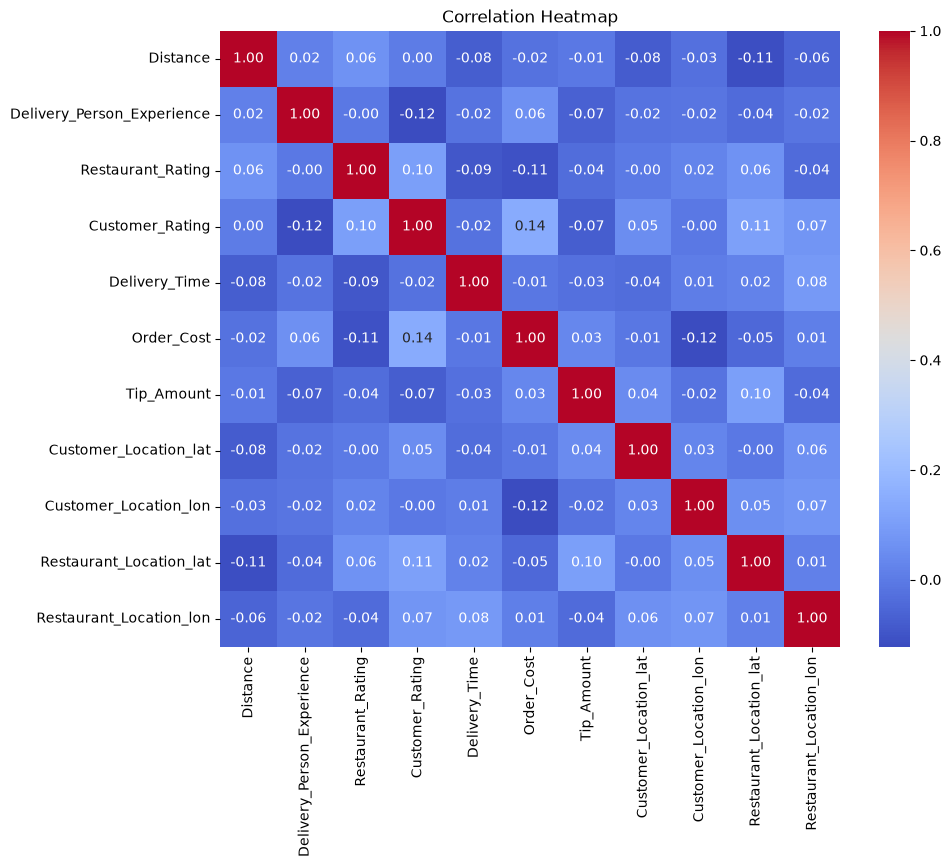

correlation with Delivery_Time:
Delivery_Time                 1.000000
Restaurant_Location_lon       0.083964
Restaurant_Location_lat       0.018548
Customer_Location_lon         0.008253
Order_Cost                   -0.009307
Delivery_Person_Experience   -0.019098
Customer_Rating              -0.021952
Tip_Amount                   -0.029154
Customer_Location_lat        -0.037146
Distance                     -0.075143
Restaurant_Rating            -0.091855
Name: Delivery_Time, dtype: float64


In [61]:
# correlation with Delivery_Time
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

print("correlation with Delivery_Time:")
print(df[num_cols].corr()['Delivery_Time'].sort_values(ascending=False))


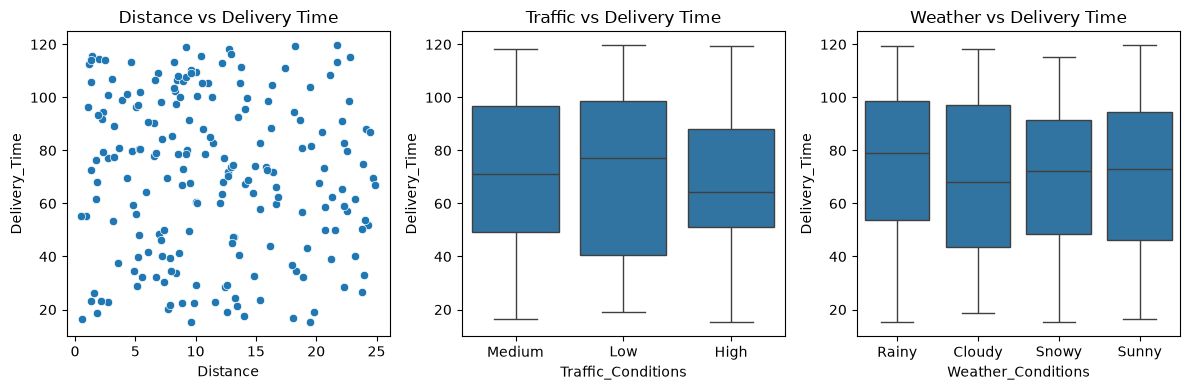

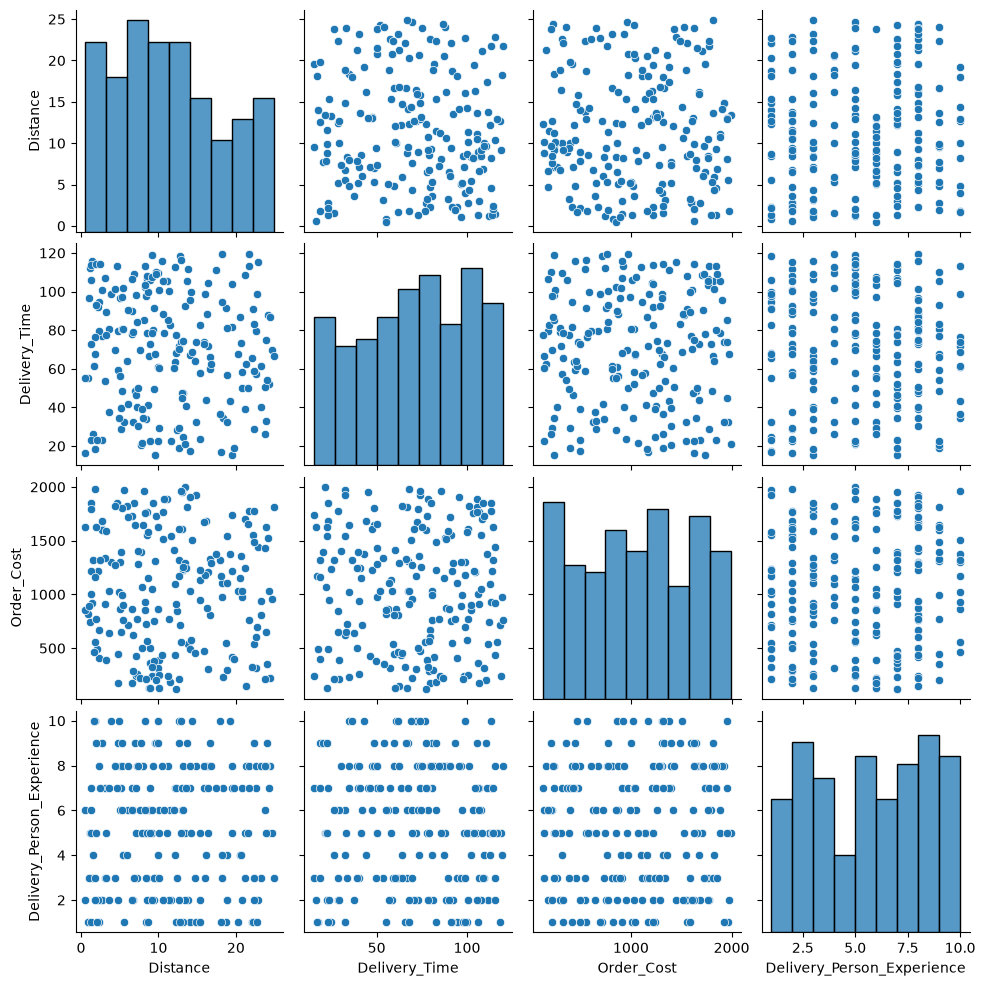

In [62]:
# quick looks - distance vs delivery time and some cats
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.scatterplot(x='Distance', y='Delivery_Time', data=df)
plt.title('Distance vs Delivery Time')

plt.subplot(1,3,2)
sns.boxplot(x='Traffic_Conditions', y='Delivery_Time', data=df)
plt.title('Traffic vs Delivery Time')

plt.subplot(1,3,3)
sns.boxplot(x='Weather_Conditions', y='Delivery_Time', data=df)
plt.title('Weather vs Delivery Time')

plt.tight_layout()
plt.show()

# pairplot for few important cols
sns.pairplot(df[['Distance','Delivery_Time','Order_Cost','Delivery_Person_Experience']])
plt.show()


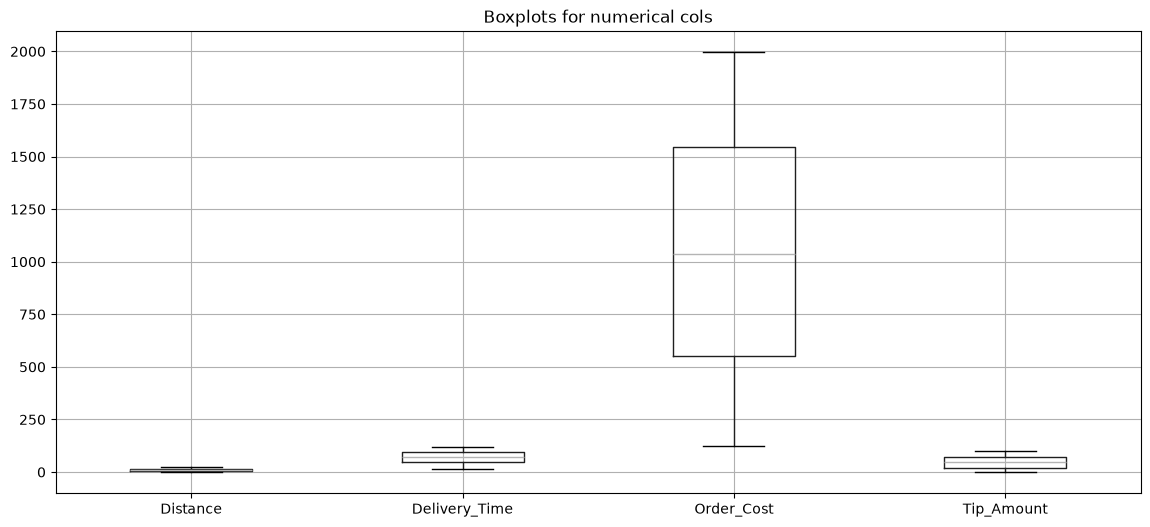

shape before: (200, 16)
shape after: (200, 16)


In [63]:
# outlier check using boxplots
plt.figure(figsize=(14,6))
df[['Distance','Delivery_Time','Order_Cost','Tip_Amount']].boxplot()
plt.title('Boxplots for numerical cols')
plt.show()

# removing extreme outliers with IQR (rough way)
def remove_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    return data[(data[col] >= lower) & (data[col] <= upper)]

print('shape before:', df.shape)
df = remove_outliers(df, 'Delivery_Time')
df = remove_outliers(df, 'Distance')
print('shape after:', df.shape)
df = df.reset_index(drop=True)


**Step 3 - Feature Engineering**

- Haversine distance from lat/lon (even though Distance already exists)
- Rush hour feature from Order_Time

In [64]:
# haversine formula to calc distance in km
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

df['Haversine_Distance'] = haversine(
    df['Customer_Location_lat'], df['Customer_Location_lon'],
    df['Restaurant_Location_lat'], df['Restaurant_Location_lon']
)

# rush hour - morning and evening usually busy
df['Rush_Hour'] = df['Order_Time'].apply(lambda x: 1 if x in ['Morning', 'Evening'] else 0)

print(df[['Distance','Haversine_Distance','Order_Time','Rush_Hour']].head(10))
print('\nrush hour counts:')
print(df['Rush_Hour'].value_counts())


   Distance  Haversine_Distance Order_Time  Rush_Hour
0      1.57          775.651198  Afternoon          0
1     21.32         1042.385597      Night          0
2      6.95          476.220706      Night          0
3     13.79          389.912629    Evening          1
4      6.72          806.505886      Night          0
5     10.00          392.168675    Evening          1
6      5.15          638.651532    Evening          1
7     22.57          849.297420    Evening          1
8     13.19          497.049109      Night          0
9     19.56          416.975418  Afternoon          0

rush hour counts:
Rush_Hour
0    104
1     96
Name: count, dtype: int64


#### **Phase 2: Predictive Modeling**

**Step 4 - Linear Regression Model**

Predict Delivery_Time using Distance, traffic, experience etc.

In [65]:
# preparing data for linear regression (simple get_dummies way)
df_model = df.copy()

df_model = pd.get_dummies(
    df_model,
    columns=['Weather_Conditions','Traffic_Conditions','Order_Priority','Order_Time','Vehicle_Type'],
    drop_first=True
)

# drop stuff we dont need for prediction
X = df_model.drop(columns=['Delivery_Time','Haversine_Distance',
                           'Customer_Location_lat','Customer_Location_lon',
                           'Restaurant_Location_lat','Restaurant_Location_lon'])
y = df_model['Delivery_Time']

print(X.columns.tolist())
print('X shape:', X.shape)


['Distance', 'Delivery_Person_Experience', 'Restaurant_Rating', 'Customer_Rating', 'Order_Cost', 'Tip_Amount', 'Rush_Hour', 'Weather_Conditions_Rainy', 'Weather_Conditions_Snowy', 'Weather_Conditions_Sunny', 'Traffic_Conditions_Low', 'Traffic_Conditions_Medium', 'Order_Priority_Low', 'Order_Priority_Medium', 'Order_Time_Evening', 'Order_Time_Morning', 'Order_Time_Night', 'Vehicle_Type_Bike', 'Vehicle_Type_Car']
X shape: (200, 19)


In [66]:
# train test split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print('Linear Regression Results:')
print('MSE:', round(mse, 3))
print('RMSE:', round(np.sqrt(mse), 3))
print('MAE:', round(mae, 3))
print('R2:', round(r2, 3))


Linear Regression Results:
MSE: 1021.936
RMSE: 31.968
MAE: 27.185
R2: -0.105


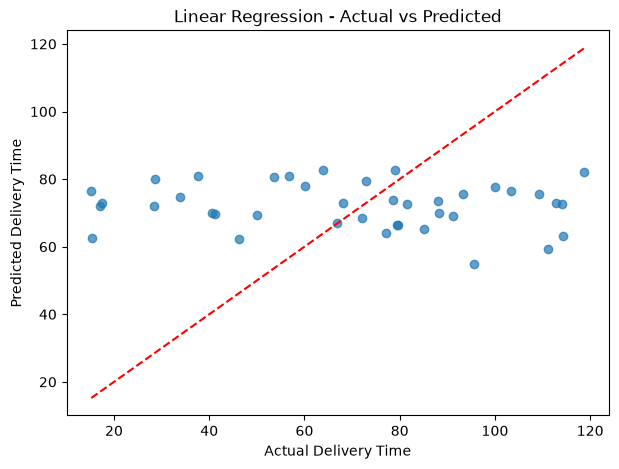

In [67]:
# scatter plot actual vs predicted
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Delivery Time')
plt.ylabel('Predicted Delivery Time')
plt.title('Linear Regression - Actual vs Predicted')
plt.show()


**Step 5 - Logistic Regression Model (for Categorization)**

Classify as Fast / Delayed. Using median Delivery_Time as cutoff.

In [68]:
# create binary target - Fast=0, Delayed=1 based on median
median_time = df['Delivery_Time'].median()
print('median delivery time:', median_time)

df_clf = df.copy()
df_clf['Delayed'] = (df_clf['Delivery_Time'] > median_time).astype(int)
print(df_clf['Delayed'].value_counts())

df_clf = pd.get_dummies(
    df_clf,
    columns=['Weather_Conditions','Traffic_Conditions','Order_Priority','Order_Time','Vehicle_Type'],
    drop_first=True
)

X_clf = df_clf.drop(columns=['Delivery_Time','Delayed','Haversine_Distance',
                             'Customer_Location_lat','Customer_Location_lon',
                             'Restaurant_Location_lat','Restaurant_Location_lon'])
y_clf = df_clf['Delayed']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

scaler2 = StandardScaler()
Xc_train_s = scaler2.fit_transform(Xc_train)
Xc_test_s = scaler2.transform(Xc_test)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(Xc_train_s, yc_train)

yc_pred = log_reg.predict(Xc_test_s)
yc_prob = log_reg.predict_proba(Xc_test_s)[:, 1]

print('\nAccuracy:', accuracy_score(yc_test, yc_pred))
print('\nClassification Report:')
print(classification_report(yc_test, yc_pred, target_names=['Fast','Delayed']))
print('Confusion Matrix:')
print(confusion_matrix(yc_test, yc_pred))


median delivery time: 72.775
Delayed
0    100
1    100
Name: count, dtype: int64

Accuracy: 0.425

Classification Report:
              precision    recall  f1-score   support

        Fast       0.39      0.37      0.38        19
     Delayed       0.45      0.48      0.47        21

    accuracy                           0.42        40
   macro avg       0.42      0.42      0.42        40
weighted avg       0.42      0.42      0.42        40

Confusion Matrix:
[[ 7 12]
 [11 10]]


#### **Phase 3: Reporting and Insights**

**Step 6 - Model Evaluation and Comparison**

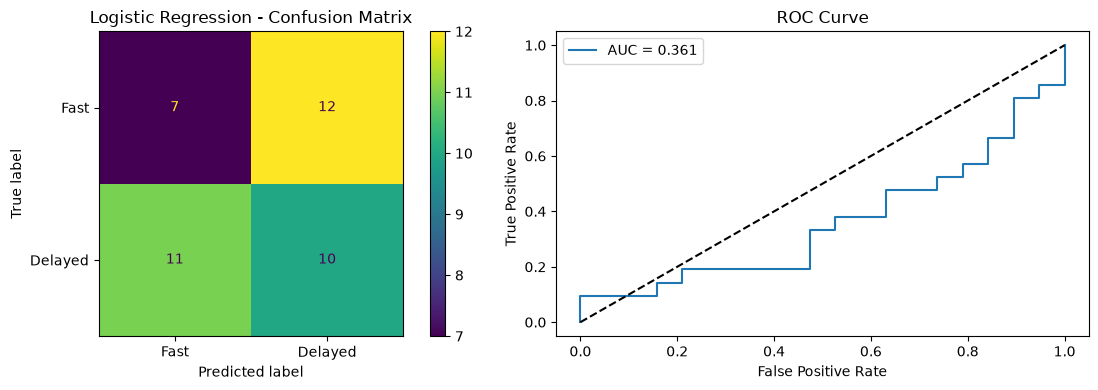

--- Comparison ---
Linear Regression -> predicts continuous Delivery_Time
  R2=-0.105, MAE=27.185, MSE=1021.936
Logistic Regression -> classifies Fast vs Delayed
  Accuracy=0.425, AUC=0.361
Both useful for different things - LR for ETA, LogReg for delay risk.


In [69]:
# confusion matrix + ROC
fig, ax = plt.subplots(1, 2, figsize=(12,4))

ConfusionMatrixDisplay.from_predictions(
    yc_test, yc_pred, display_labels=['Fast','Delayed'], ax=ax[0]
)
ax[0].set_title('Logistic Regression - Confusion Matrix')

fpr, tpr, _ = roc_curve(yc_test, yc_prob)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
ax[1].plot([0,1],[0,1],'k--')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('ROC Curve')
ax[1].legend()
plt.tight_layout()
plt.show()

print('--- Comparison ---')
print('Linear Regression -> predicts continuous Delivery_Time')
print(f'  R2={r2:.3f}, MAE={mae:.3f}, MSE={mse:.3f}')
print('Logistic Regression -> classifies Fast vs Delayed')
print(f'  Accuracy={accuracy_score(yc_test, yc_pred):.3f}, AUC={roc_auc:.3f}')
print('Both useful for different things - LR for ETA, LogReg for delay risk.')


**Step 7 - Actionable Insights / Final Report (rough notes)**

**Dataset & preprocessing**
- 200 rows, no missing values found
- Split lat/lon from location strings
- Encoded weather, traffic, priority, order time, vehicle type (get_dummies / one-hot)
- Standardized numeric features for models
- Made Rush_Hour from Morning/Evening
- Also computed Haversine distance from coords (Distance column already exists though)

**Model evaluation**
- Linear Regression: predicts continuous Delivery_Time (see R2/MAE above)
- Logistic Regression: Fast vs Delayed using median cutoff (see accuracy + ROC)
- Scores are not amazing — correlations with Delivery_Time are weak in this dataset, so models struggle a bit. Still completed full pipeline.

**Recommendations (if this was real ops data)**
1. Optimize routes when Distance is high / traffic is High
2. Staff more during Rush_Hour (Morning & Evening)
3. Prefer faster Vehicle_Type (Bike/Car) in bad Weather / High traffic
4. Give more training to low-experience delivery persons
5. Use delay classifier to flag risky orders and warn customers early

**Full detailed report:** see `Final_Report.md` (dataset, preprocessing, model comparison, recommendations).
